In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv("N:/dep_coupland/grp_fulgione/mehak/data/spanish_project/pn_ps_dn_ds_logistic_regression/dn_ds_simple/statistics_per_gene_substitution_g2_g5_filter_low_pvt_var_5_pr_wald0.016631363015617805_gee.tsv",sep="\t")


In [3]:
import gffpandas.gffpandas as gffpd


In [4]:
annotation = gffpd.read_gff3("N:/dep_coupland/grp_fulgione/mehak/software/ka_ks/annotation/Arabis_alpina_mpipz_v5.1_annotation.gff")


In [5]:
combined_df = annotation.filter_feature_of_type(['gene'])
genes_df=combined_df.attributes_to_columns()

In [6]:
genes_df.columns=['seq_id', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase',
       'attributes', 'Alias', 'Dbxref', 'ID', 'gene', 'Note', 'Ontology_term',
       'date_creation', 'date_last_modified', 'description', 'owner']

In [7]:
stats=df

In [8]:
genes_data=pd.merge(stats,genes_df, on="gene")


In [9]:
mask=pd.read_csv("I:/dep_coupland/grp_fulgione/common/1000Genomes/ParaMask_SNPable_combined_masks/ParaMask_Cantabria_and_French_30PerMiss_v3_EM2.7.1_EMresults.chrall.finalClass.multicopy.ZeroBasedStart.SNPable.3col.sorted.merged.bed", sep="\t", header=None)
mask.columns=["chr","start","end"]

In [10]:
def region_in_mask(chrom, start_r, end_r, mask):
    mask_chr=mask[mask["chr"]==chrom]
    mask_chr_s=mask_chr[(mask_chr["start"]<start_r) & (mask_chr["end"]>start_r)]
    mask_chr_e=mask_chr[(mask_chr["start"]<end_r) & (mask_chr["end"]>end_r)]
    mask_chr_1=mask_chr[(mask_chr["start"]>start_r) & (mask_chr["end"]<end_r)]
    mask_chr_2=mask_chr[(mask_chr["start"]<start_r) & (mask_chr["end"]>end_r)]
    if len(mask_chr_s)==0 and len(mask_chr_e)==0 and len(mask_chr_1)==0 and len(mask_chr_2)==0:
        return("no")
    else:
        return ("yes")

In [11]:
multi_copy_regions=[]
for i in genes_data.index:
    multi_copy_regions.append(region_in_mask(genes_data["seq_id"][i],int(genes_data["start"][i]),int(genes_data["end"][i]),mask))

In [16]:
genes_data["multi_copy"]=multi_copy_regions
genes_data_mutli=genes_data[genes_data["multi_copy"]=="no"]

In [17]:
genes_data_mutli=genes_data_mutli[["gene","OR","coeff","pvalues","bse","wald_p"]]


In [18]:
paramask=list(genes_data_mutli["gene"])

In [19]:
import numpy as np

In [20]:
np.log(genes_data_mutli["OR"].mean())

0.016631363015617805

<Axes: xlabel='coeff', ylabel='Count'>

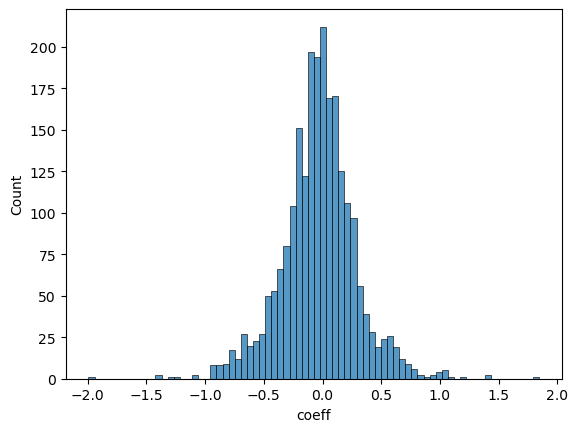

In [21]:
sns.histplot(genes_data_mutli["coeff"])

<Axes: xlabel='wald_p', ylabel='Count'>

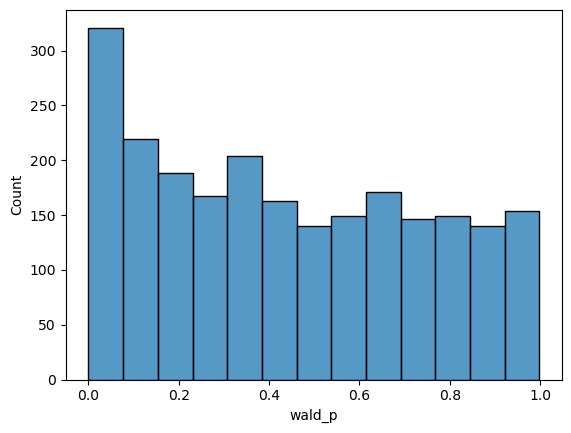

In [22]:
sns.histplot(genes_data_mutli["wald_p"])


In [23]:
import statsmodels.stats.multitest


In [24]:
genes_data_mutli["multi_pvalue_wald"]=statsmodels.stats.multitest.multipletests(genes_data_mutli["wald_p"], alpha=0.05, method='fdr_bh', maxiter=1, is_sorted=False, returnsorted=False)[1]


In [25]:
genes_data_mutli[genes_data_mutli["multi_pvalue_wald"]<=0.05]


,gene,OR,coeff,pvalues,bse,wald_p,multi_pvalue_wald
409,AA1G30250,0.704918,-0.349674,0.000024,0.082839,0.000010,0.022613
952,AA2G20390,0.700000,-0.356675,0.000117,0.092582,0.000055,0.042572
2153,AA4G34590,0.457143,-0.782759,0.000053,0.193649,0.000037,0.042277


In [26]:
genes_data_mutli[genes_data_mutli["multi_pvalue_wald"]<=0.06]


,gene,OR,coeff,pvalues,bse,wald_p,multi_pvalue_wald
409,AA1G30250,0.704918,-0.349674,0.000024,0.082839,0.000010,0.022613
952,AA2G20390,0.700000,-0.356675,0.000117,0.092582,0.000055,0.042572
2153,AA4G34590,0.457143,-0.782759,0.000053,0.193649,0.000037,0.042277
